**Indroduction**

This project explores and compares three deep learning approaches to classify emotions in tweets: Convolutional Neural Networks (CNN), Long Short-Term Memory networks (LSTM), and a transformer-based pre-trained model called BERTweet.

**Data Sources**

The data of the group project is emotion-classification dataset on huggingface website. (https://huggingface.co/datasets/dair-ai/emotion)

**Exploratory Analysis of Data (Details about the properties and number of classes)**

The feature of the data is a sentence expressing emotion, and the label is from 0-5, representing emotion of sadness, joy, love, anger, fear and surprise. The original data contains over 400 thousand samples without order. Randomly selecting 8000 samples of each class and combining them together comprises the trainnig data, and combining 2000 samples of 6 classes for test and validation.

Epoch 1, Loss: 2688.4826, average loss:1.7923, accuracy:16.56%
Validation Loss: 1.7918, Validation Accuracy: 16.70%
Epoch 2, Loss: 2688.0233, average loss:1.7920, accuracy:17.03%
Validation Loss: 1.7919, Validation Accuracy: 16.88%
Epoch 3, Loss: 2682.7002, average loss:1.7885, accuracy:17.30%
Validation Loss: 1.7918, Validation Accuracy: 17.03%
Epoch 4, Loss: 2664.0306, average loss:1.7760, accuracy:18.14%
Validation Loss: 1.7965, Validation Accuracy: 16.91%
Epoch 5, Loss: 2635.9871, average loss:1.7573, accuracy:19.43%
Validation Loss: 1.7569, Validation Accuracy: 20.88%
model is saved

 -------LSTM model evaluation--------
Accuracy: 0.20875


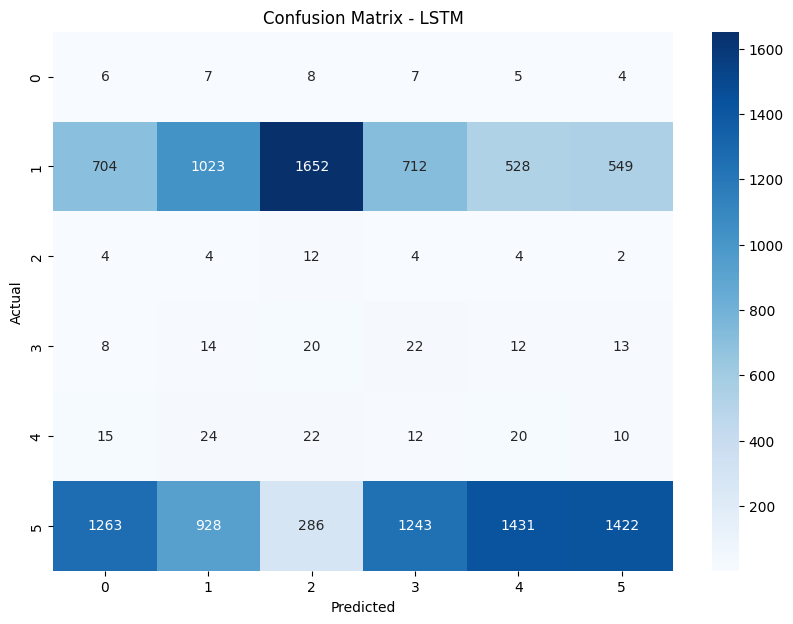

In [ ]:
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader
import torch
import re
from collections import Counter
import torch
import torch.nn as nn
from torch.optim import Adam
import math
import matplotlib.pyplot as plt
import seaborn 
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# evaluate part


def evaluate_model(y_true, y_pred, model_name):
    print(f"\n -------{model_name} model evaluation--------")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,7))
    seaborn.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# data process part

def tokenize(text):
    # Simple tokenizer: lowercase, remove non-letters, split by space
    #lowercase the word
    text = text.lower()
    #remove the characters that not lowercase or spaces us re to achieve this
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

def build_vocab(texts, min_freq=2):
    #calculate the word appear in the centances
    counter = Counter()
    for text in texts:
        tokens = tokenize(text)
        counter.update(tokens)
    
    #initial PAD and UNKNOW to record the padding and unknown words
    vocab = {'<PAD>': 0, '<UNK>': 1}
    #teh vocab dictionary does not store word frequencies it only maps each word to a unique integer index
    for word, freq in counter.items():
        #match the min number limit
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len):
    #convert the word to ID
    #get text from the dataframe
    tokens = tokenize(text)
    #find the word's id in vocab and get the ID as an array
    ids = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    #the output is like [5, 9,6 00 0 0]
    if len(ids) < max_len:
        ids += [vocab['<PAD>']] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

class LSTMDataset(Dataset):
    def __init__(self, dataframe, vocab, max_len=100):
        #get the text and label from csv
        self.texts = dataframe['text'].tolist()
        self.labels = dataframe['label'].tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        input_ids = torch.tensor(encode(text, self.vocab, self.max_len), dtype=torch.long)
        return {
            'input_ids': input_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

def processed_LSTM(df, vocab=None, max_len=50):
    if vocab is None:
        vocab = build_vocab(df['text'])
    return LSTMDataset(df, vocab, max_len), vocab

# LSTM part

class LSTM_model(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_hid, num_out, batch_size=1, num_layers=1):
        #vocab_size is the total number of words in vocabulery
        #embed_dim is the size of each word vector
        #num_hid is the hidden layer size
        #the number of emotion classes
        #batch_size and num_layer will include for future scalability
        # inherit the model init from nn.module
        super().__init__()
        #initial the value in init
        self.num_hid = num_hid
        self.batch_size = batch_size
        self.num_layer = num_layers
        
        #embedding the layer, convert a sequence of word induces into vectors
        #Input shape: (batch_size, seq_len) → Output: (batch_size, seq_len, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        #changer the parameter to configous LSTM
        #W is the input -to-hidden weight
        #U is the weight between hidden layer
        #hid_bias is bias for 4 LSTM gates
        self.W = nn.Parameter(torch.Tensor(embed_dim, num_hid * 4))
        self.U = nn.Parameter(torch.Tensor(num_hid, num_hid * 4))
        self.hid_bias = nn.Parameter(torch.Tensor(num_hid * 4))
        
        #set output layer
        self.V = nn.Parameter(torch.Tensor(num_hid, num_out))
        self.out_bias = nn.Parameter(torch.Tensor(num_out))
        
        self.init_weight()
        
        #after set the parameter of each layer, initial the weight
    def init_weight(self):
        stdv = 1.0/math.sqrt(self.num_hid)
        for weight in self.parameters():
            weight.data.uniform_(-stdv,stdv)
    
    #define the forward function to puch forward
    def forward(self, x, init_state = None):
        #(bartch, seq_len, embed_dim)
        x = self.embedding(x)
        batch_size, seq_size, _= x.size()
        hidden_seq = []
        if init_state is None:
            #h_t is hidden state, adn c_ t is cell state
            
            h_t = torch.zeros(batch_size, self.num_hid).to(x.device)
            c_t = torch.zeros(batch_size, self.num_hid).to(x.device)
        else:
            h_t, c_t = init_state
        
        NH = self.num_hid
        #go over each word in the sequence
        for t in range(seq_size):
            #input vector at time step t :measns all bath, time step t and all feature in the embedding vector
            x_t = x[:, t, :]
            #calculate all 4 gates at once
            #LSTM have 4 gate use the weight between each layer and bias to calculate the gates
            gates = x_t @ self.W + h_t @ self.U + self.hid_bias
            #input gate, forget gate, cell candidate and output gate
            i_t, f_t, g_t, o_t = (
                #use sigmoid to make partition keep (0,1) and use tanh to keep (-1,1)
                #c_t = f_t * c_t + i_t * g_t  # updated cell state
                #h_t = o_t * torch.tanh(c_t)  # updated hidden state (output)
                torch.sigmoid(gates[:,:NH]), #input gate
                torch.sigmoid(gates[:, NH:NH * 2]), #forget gate
                torch.tanh(gates[:, NH *2:NH *3]),  #cell candidate
                torch.sigmoid(gates[:, NH*3:])  #output gate
            )
            #standard LSTM equations
            #c_t combines past memory and new input
            #h_t filtered memory passed to the next step
            c_t = f_t * c_t + i_t * g_t
            h_t = o_t * torch.tanh(c_t)
            #add a dimension in front of tensor
            #this step will give a room to save the length of the sequence
            hidden_seq.append(h_t.unsqueeze(0))
        #stack and reorder the hidden states to make them batch-first. cat is to replace the unsequeeze room in dim = 0
        hidden_seq = torch.cat(hidden_seq, dim= 0)
        #change the place of seq_len and batch size
        hidden_seq = hidden_seq.transpose(0, 1).contiguous()
        
        #in last timestep and all batch and all feature
        final_hidden = hidden_seq[:, -1, :] 
        output = final_hidden @ self.V + self.out_bias
        
        return output  

# training part

path_train = os.path.join("data", "combined_shuffled_8000.csv")
path_validation = os.path.join("data", "combined_shuffled_2000.csv")
path_save = os.path.join("net", "lstm_model.pth")
train_data = pd.read_csv(path_train)
v_data = pd.read_csv(path_validation)


def LSTM_train(model, device, train_loader, validation_loader_LSTM, optimizer,criterion, epoch):
    #train model
    #let model training 
    model.train()
    
    #set the epoch
    for i in range(epoch):
        #recode the total loss
        total_loss = 0
        correct = 0
        total = 0
        #get data in loader like{input_ids,labels}
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            #evaluate
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        avg_loss = total_loss / len(train_loader)
        acc = correct / total
        print(f"Epoch {i+1}, Loss: {total_loss:.4f}, average loss:{avg_loss:.4f}, accuracy:{acc:.2%}")
        #test overfitting
        val_loss, val_acc,_,_ = validation(model, device, validation_loader_LSTM, criterion)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2%}")

    torch.save(model.state_dict(), path_save)
    print("model is saved")

#validation function to test overfitting
def validation(model, device, val_loader, criterion):
    # base attribute for accuracy and confusion matrix
    model.eval()  # Turn off dropout, etc.
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    # set gradient not change
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids)
            # in validation it dont need optimizer and backword
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels

    

def main():
    #main train function first need load the load data and process it 
    #second need load train manipulate
    #dara process
    #bert
    #file_bert = processed_BERT(file) 
    #train_loader_BERT = DataLoader(file_bert, batch_size = 16, shuffle = True)
    #LSTM
    train_dataset_LSTM, vocab = processed_LSTM(train_data, max_len = 50)
    train_loader_LSTM = DataLoader(train_dataset_LSTM, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    n = len(vocab)


    #load validation data
    validation_dataset_LSTM, _ =processed_LSTM(v_data,vocab=vocab, max_len= 50)
    validation_loader_LSTM = DataLoader(validation_dataset_LSTM, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    
    #device use GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    #model select
    model1 = LSTM_model(vocab_size = n, embed_dim= 100, num_hid= 128, num_out= 6).to(device)
    #loade pretrain model



    #model2 = BERT_model().to(device)
    
    #optimizer select
    optimizer = Adam(model1.parameters(), lr = 1e-3)
    
    #epoch set
    epoch = 5
    
   
    #loss function
    criterion = nn.CrossEntropyLoss()
    
    #trainning
    LSTM_train(model1, device, train_loader_LSTM,validation_loader_LSTM, optimizer,criterion, epoch)
    _,_, y_pred, y_true = validation(model1, device, validation_loader_LSTM, criterion)
    evaluate_model(y_pred, y_true, "LSTM")

if __name__ == '__main__':
    main()


**data_process of LSTM**

Simple tokenizer: lowercase, remove non-letters, split by space, and lowercase the word, then Loops through all text, tokenizes it, and counts how often each word appears.

Initializes a vocabulary with special tokens: which will Adds words that occur at least min_freq times. 

after this Tokenizes the text,Converts tokens to IDs using the vocab Pads or truncates the sequence to max_len

initial LSTM dataset need len and getitem method because the dataload will automatically use it 


**LSTM model**

in LSTM model have 3 gates, which are input, forget and output gate and a update value, gate use sigmoid to make value in range(0,1), and update value use tenh activation function make value in range(-1, 1)

X_t is the input embedding vector of this time step 
Ht_1 is the hidden state of previous time step, c t-1 is previous cell state, those are previous term memory
the forget gate is decide the previous term output effect in this time step,
and gt is update value input gate will decide the ratio of update value add to the cell state
output gate is used to decide which tanh of the context unit values will be used in next time step as previous hidden unit value
the output of each time step can be supervised so it is good for configure 

the embedding affect the ability of different sequence processing slgorithms to learn long range dependencies.


**result of LSTM**

i separete 10 epoch as two 5 epoch to training the model, which will more efficient and save runtime, because the pre-trained model can make model learning faster than a new model from scratch

Epoch 1, Loss: 2155.3677, average loss:1.4369, accuracy:41.31%
Validation Loss: 1.5715, Validation Accuracy: 32.53%
Epoch 2, Loss: 1718.5672, average loss:1.1457, accuracy:55.31%
Validation Loss: 1.0195, Validation Accuracy: 59.79%
Epoch 3, Loss: 1019.3005, average loss:0.6795, accuracy:76.58%
Validation Loss: 0.5769, Validation Accuracy: 82.17%
Epoch 4, Loss: 537.6210, average loss:0.3584, accuracy:89.67%
Validation Loss: 0.3704, Validation Accuracy: 89.23%
Epoch 5, Loss: 409.6269, average loss:0.2731, accuracy:91.79%
Validation Loss: 0.3383, Validation Accuracy: 89.64%
model is saved

 -------LSTM model evaluation--------
Accuracy: 0.8964166666666666


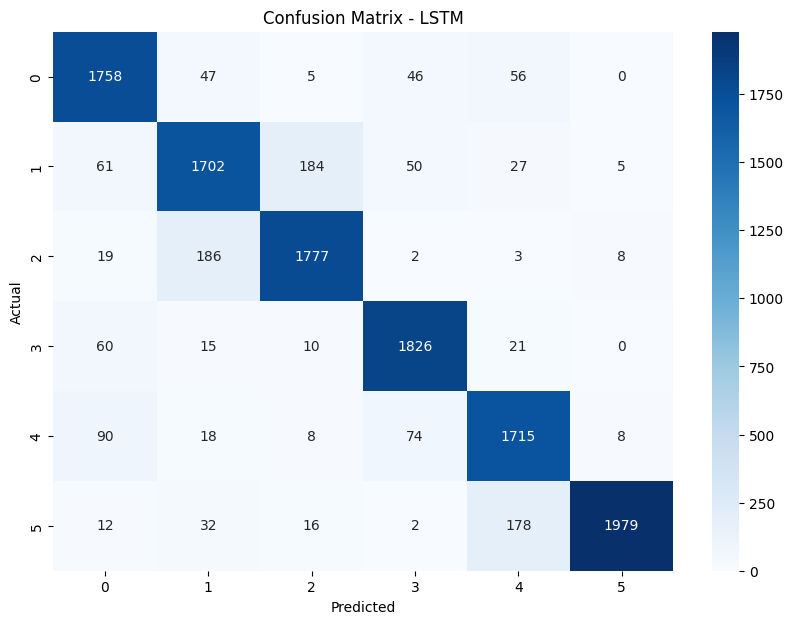

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import os
import pickle
from torch.optim import Adam
from model_class import LSTM_model
from torchvision import datasets
from torch.utils.data import DataLoader


path_train = os.path.join("data", "combined_shuffled_8000.csv")
path_validation = os.path.join("data", "combined_shuffled_2000.csv")
path_save = os.path.join("net", "lstm_model.pth")
train_data = pd.read_csv(path_train)
v_data = pd.read_csv(path_validation)


def LSTM_train(model, device, train_loader, validation_loader_LSTM, optimizer,criterion, epoch):
    #train model
    #let model training 
    model.train()
    
    #set the epoch
    for i in range(epoch):
        #recode the total loss
        total_loss = 0
        correct = 0
        total = 0
        #get data in loader like{input_ids,labels}
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            #evaluate
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        avg_loss = total_loss / len(train_loader)
        acc = correct / total
        print(f"Epoch {i+1}, Loss: {total_loss:.4f}, average loss:{avg_loss:.4f}, accuracy:{acc:.2%}")
        #test overfitting
        val_loss, val_acc,_,_ = validation(model, device, validation_loader_LSTM, criterion)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2%}")

    torch.save(model.state_dict(), path_save)
    print("model is saved")

#validation function to test overfitting
def validation(model, device, val_loader, criterion):
    # base attribute for accuracy and confusion matrix
    model.eval()  # Turn off dropout, etc.
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    # set gradient not change
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids)
            # in validation it dont need optimizer and backword
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels

    

def main():
    #main train function first need load the load data and process it 
    #second need load train manipulate
    #dara process
    #bert
    #file_bert = processed_BERT(file) 
    #train_loader_BERT = DataLoader(file_bert, batch_size = 16, shuffle = True)
    #LSTM
    train_dataset_LSTM, vocab = processed_LSTM(train_data, max_len = 50)
    train_loader_LSTM = DataLoader(train_dataset_LSTM, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    n = len(vocab)
    # save vocab to pickel use it in test time


    #load validation data
    validation_dataset_LSTM, _ =processed_LSTM(v_data,vocab=vocab, max_len= 50)
    validation_loader_LSTM = DataLoader(validation_dataset_LSTM, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    
    #device use GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    #model select
    model1 = LSTM_model(vocab_size = n, embed_dim= 100, num_hid= 128, num_out= 6)
    #loade pretrain model

    model1.load_state_dict(torch.load(path_save, weights_only= True))
    model1.to(device)
    model1.eval()

    #model2 = BERT_model().to(device)
    
    #optimizer select
    optimizer = Adam(model1.parameters(), lr = 1e-3)
    
    #epoch set
    epoch = 5
    
   
    #loss function
    criterion = nn.CrossEntropyLoss()
    
    #trainning
    LSTM_train(model1, device, train_loader_LSTM,validation_loader_LSTM, optimizer,criterion, epoch)
    _,_, y_pred, y_true = validation(model1, device, validation_loader_LSTM, criterion)
    evaluate_model(y_pred, y_true, "LSTM")

if __name__ == '__main__':
    main()

**result of LSTM**

use first 5 epoch model as pre-trained model will drastically improve the training and validation accuracy, during the training time the batch_size in torch.dataload will affect the training accuracy and the runtime.


C:\Users\刘路泽\AppData\Local\Temp\ipykernel_19820\1769756442.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(trained_path))



 -------LSTM model evaluation--------
Accuracy: 0.8965833333333333


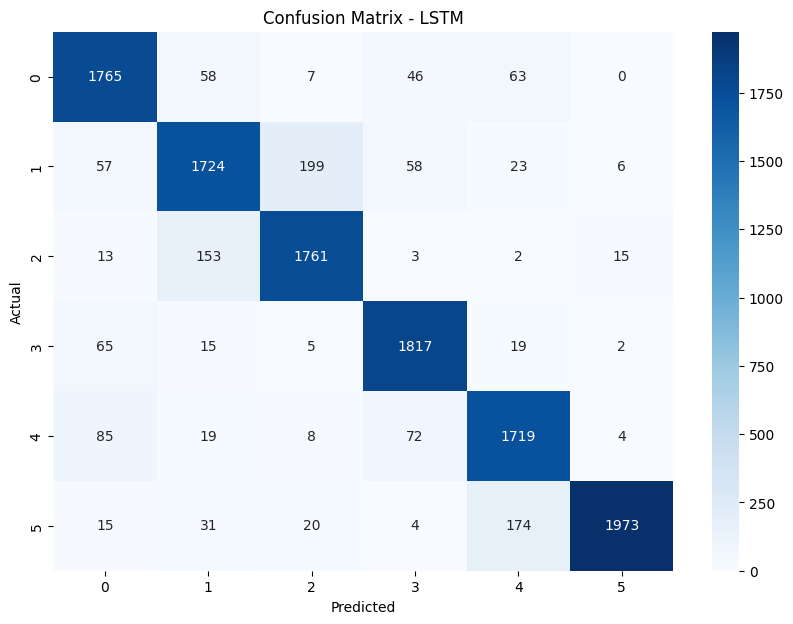

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90      1939
           1       0.86      0.83      0.85      2067
           2       0.88      0.90      0.89      1947
           3       0.91      0.94      0.93      1923
           4       0.86      0.90      0.88      1907
           5       0.99      0.89      0.94      2217

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



In [5]:
import os
import torch
import pandas as pd
import pickle
from torch.utils.data import DataLoader
from model_class import LSTM_model
from data_process import processed_LSTM
from evaluate import evaluate_model
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report


device = torch.device("cuda")

# get test data from the datasetr
test_path = os.path.join("data", "combined_testdata.csv")
test_data = pd.read_csv(test_path)
trained_path = os.path.join("net", "lstm_model.pth")

# load the vocab
with open("net/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)
# load data to tensor
test_datas, vocab = processed_LSTM(test_data, vocab=vocab, max_len= 50)
# when shuffle  = True in each epoch the order of your data will randomized
test_loader_LSTM = DataLoader(test_datas, batch_size= 32, shuffle=False, num_workers= 0, pin_memory=True)

# load LSTM model
model = LSTM_model(vocab_size= len(vocab), embed_dim= 100, num_hid= 128, num_out= 6)
# load trained model
model.load_state_dict(torch.load(trained_path))
model.to(device)
model.eval()

all_preds = []
all_label = []

with torch.no_grad():
    for batch in test_loader_LSTM:
        input_ids = batch['input_ids'].to(device)
        label = batch['labels'].to(device)
        
        # get output
        output = model(input_ids)
        preds = output.argmax(1)
        
        # save predict and label
        all_preds.extend(preds.cpu().numpy())
        all_label.extend(label.cpu().numpy())

evaluate_model(all_preds, all_label, "LSTM")
print("Classification Report:\n", classification_report(all_preds, all_label))

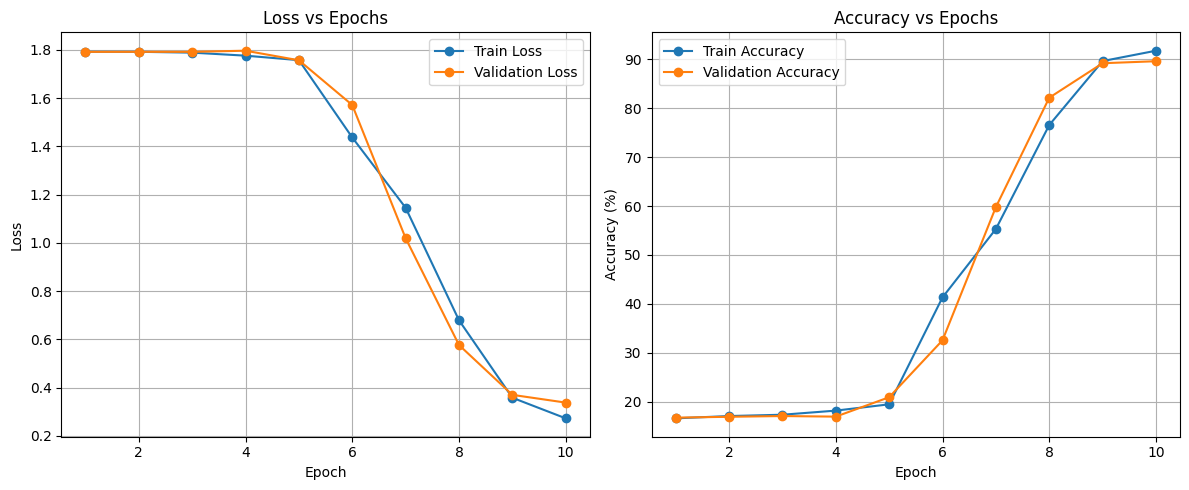

In [3]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4, 5,6,7,8,9,10]

# Training metrics
train_loss = [1.7923,1.7920, 1.7885,1.7760, 1.7573, 1.4369, 1.1457, 0.6795, 0.3584, 0.2731]
train_accuracy = [16.56,17.03, 17.30, 18.14, 19.43, 41.31, 55.31, 76.58, 89.67, 91.79]

# Validation metrics
val_loss = [1.7918,1.7919,1.7918,1.7965,1.7569,1.5715, 1.0195, 0.5769, 0.3704, 0.3383]
val_accuracy = [16.70, 16.88, 17.03,16.91, 20.88, 32.53, 59.79, 82.17, 89.23, 89.64]

# Plotting
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Discussion**

After 10 training epoch, the highest accuracy of validation dataset is 89.64% and for the test data accuracy is 89.64%. By analyzing the confusion matrix, it can be easily found that  'fear', and hard to found 'surprise'. The reson is that the model is not completely trained, and the 'surprise' is harder to identify than other emotion.

Back to the LSTM, the one of the **strengths** of the model is that during the training time we can suprvise the hidden layer output in each time step which is more efficient to configent. The **weaknesses** are also obvious. The model need more epoch to train compare to the BRET and CNN. Regarding **future work**, increase the training epoch to increase the congregate of feature therefore improve the accuracy, or add data augmentation to increase accuracy